# Hybrid - APG Approach
## Full Implementation 
### Let $F(x) = |x| + \mathcal{I}_C(x)$ where $\mathcal{I}_C$ is the indicator function of the nonnegative orthant $C = \{x \ge 0\}$.

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import time
from typing import Callable, Optional, Tuple



# Simple Problem setup



In [32]:
def smooth_abs(x, mu=0.1):
    return np.sqrt(x**2 + mu**2) - mu

def smooth_abs_grad(x, mu=0.1):
    return x / np.sqrt(x**2 + mu**2)

# Proximal of both indicator and Abs


In [33]:
def prox_indicator(v, alpha=1.0, constraint='nonneg'):
    if constraint == 'nonneg':
        return np.maximum(v, 0)
    elif constraint == 'box':
        return np.clip(v, 0, 1)
    elif constraint == 'unbounded':
        return v
    else:
        return v


def prox_abs(v, alpha=1.0):
    return np.sign(v) * np.maximum(np.abs(v) - alpha, 0)

# Objective Function

In [34]:
def F(x):
    return np.sum(np.abs(x)) + (0 if np.all(x >= 0) else np.inf)

def smooth_part(x, mu=0.1):
    return np.sum(smooth_abs(x, mu))

def smooth_part_grad(x, mu=0.1):
    return smooth_abs_grad(x, mu)

def F(x, constraint='nonneg', tol=1e-10):
    # Check constraint with tolerance
    if constraint == 'nonneg':
        if np.any(x < -tol):
            return np.inf
    elif constraint == 'box':
        if np.any(x < -tol) or np.any(x > 1 + tol):
            return np.inf
    
    # Return |x| sum
    return np.sum(np.abs(x))

# Original PG,APG


In [35]:
def pg(x0, grad_f, prox_g, F, alpha, max_iter=1000):
    x = x0.copy()
    obj = [F(x)]
    for _ in range(max_iter):
        x = prox_g(x - alpha * grad_f(x), alpha)
        obj.append(F(x))
    return x, np.array(obj)

def apg(x0, grad_f, prox_g, F, alpha, max_iter=1000):
    """
    Update rules:
        x^{k+1} = prox_{alpha g}(y^k - alpha * grad_f(y^k))
        t_{k+1}  = (1 + sqrt(1 + 4 t_k^2)) / 2
        y^{k+1}  = x^{k+1} + (t_k - 1)/t_{k+1} * (x^{k+1} - x^k)
    """
    x = x0.copy()
    y = x0.copy()
    t = 1.0
    obj = [F(x)]
    for _ in range(max_iter):
        x_new = prox_g(y - alpha * grad_f(y), alpha)
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        y = x_new + (t - 1) / t_new * (x_new - x)
        x, t = x_new, t_new
        obj.append(F(x))
    return x, np.array(obj)

# Original DRS, ADRS

In [36]:
def drs(x0, prox1, prox2, F, alpha_drs=1.0, max_iter=1000, constraint='nonneg'):
    z = x0.copy()
    x = prox1(z, alpha_drs)
    x = prox_indicator(x, alpha_drs, constraint) 
    x_sum = x.copy()
    obj = [F(x, constraint)]
    
    for k in range(max_iter):
        u = prox2(2 * x - z, alpha_drs, constraint)
        z = z + u - x
        x = prox1(z, alpha_drs)
        x = prox_indicator(x, alpha_drs, constraint) 
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2), constraint))
    
    return x, np.array(obj)

def adrs(z0, prox1, prox2, F, alpha_drs=1.0, max_iter=1000, constraint='nonneg'):
    z = z0.copy()
    z_prev = z0.copy()
    t = 1.0
    x = prox1(z, alpha_drs)
    x = prox_indicator(x, alpha_drs, constraint) 
    x_sum = x.copy()
    obj = [F(x, constraint)]
    
    for k in range(max_iter):
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        beta = (t - 1) / t_new
        y = z + beta * (z - z_prev)
        x = prox1(y, alpha_drs)
        x = prox_indicator(x, alpha_drs, constraint)  
        u = prox2(2 * x - y, alpha_drs, constraint)
        z_prev = z
        z = y + u - x
        t = t_new
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2), constraint))
    
    return x, np.array(obj)

# Hybrid APG-DRS Algorithm


Let $F(x) = |x| + \mathcal{I}_C(x)$ where $\mathcal{I}_C$ is the indicator function of the nonnegative orthant $C = \{x \ge 0\}$.

Define the smooth surrogate of $|x|$ as:
$$\tilde{f}_\mu(x) = \sqrt{x^2 + \mu^2} - \mu$$
with gradient:
$$\nabla \tilde{f}_\mu(x) = \frac{x}{\sqrt{x^2 + \mu^2}}$$

## Algorithm Steps

**Input:** $x_0$ (initial point), $\mu > 0$ (smoothing parameter), $\alpha > 0$ (DRS parameter), $K$ (max iterations)

**Initialize:**
- $x = \text{proj}_C(x_0)$
- $y = x_0$
- $t = 1$
- $\bar{x} = x$
- $\text{obj}_0 = F(x)$

**For** $k = 0, 1, \ldots, K-1$ **do:**

### Step 1: APG Step on Smooth Surrogate
$$z_{\text{apg}} = y - \mu \nabla \tilde{f}_\mu(y)$$

### Step 2: DRS Correction
Set $z = z_{\text{apg}}$, $z_{\text{prev}} = z_{\text{apg}}$, $t_{\text{drs}} = 1$

$$t_{\text{drs}}^+ = \frac{1 + \sqrt{1 + 4t_{\text{drs}}^2}}{2}$$
$$\beta_{\text{drs}} = \frac{t_{\text{drs}} - 1}{t_{\text{drs}}^+}$$
$$y_{\text{drs}} = z + \beta_{\text{drs}}(z - z_{\text{prev}})$$
$$x_{\text{prox}} = \text{prox}_{\alpha|\cdot|}(y_{\text{drs}}) = \text{sign}(y_{\text{drs}}) \cdot \max(|y_{\text{drs}}| - \alpha, 0)$$
$$u = \text{proj}_C(2x_{\text{prox}} - y_{\text{drs}})$$
$$z_{\text{new}} = y_{\text{drs}} + u - x_{\text{prox}}$$
$$x_{\text{new}} = \text{proj}_C(x_{\text{prox}})$$

### Step 3: APG Momentum Update
$$t_{\text{apg}}^+ = \frac{1 + \sqrt{1 + 4t^2}}{2}$$
$$\beta_{\text{apg}} = \frac{t - 1}{t_{\text{apg}}^+}$$
$$y = x_{\text{new}} + \beta_{\text{apg}}(x_{\text{new}} - x)$$

### Step 4: Variable Updates
$$x = x_{\text{new}}$$
$$t = t_{\text{apg}}^+$$
$$\bar{x} = \bar{x} + x$$

### Step 5: Track Objective
$$\text{obj}_{k+1} = F\left(\frac{\bar{x}}{k+2}\right)$$

**Output:** $x$, $\{\text{obj}_k\}_{k=0}^{K}$

## Key Operators

**Proximal of absolute value:**
$$\text{prox}_{\alpha|\cdot|}(v) = \max(|v| - \alpha, 0) \cdot \text{sign}(v)$$

**Projection onto nonnegative orthant:**
$$\text{proj}_C(v) = \max(v, 0)$$

**Original objective:**
$$F(x) = \|x\|_1 + \mathcal{I}_C(x) = 
\begin{cases}
\sum_i |x_i| & \text{if } x_i \ge 0 \ \forall i \\
\infty & \text{otherwise}
\end{cases}$$

## Parameters

- $\mu$: Smoothing parameter (can tune but right now: 0.2) - controls accuracy of $\tilde{f}_\mu$ approximation to $|x|$
- $\alpha$: DRS step size 
- $K$: Maximum iters

In [37]:
# General hybrid alg for strict nonsmooth, nonsmooth problem

def hybrid_apg_drs(x0, mu=0.2, alpha_drs=1.0, max_iter=1000, constraint='nonneg', verbose=False):
    x = x0.copy()
    y = x0.copy()
    t = 1.0
    x = prox_indicator(x, alpha_drs, constraint)  
    x_sum = x.copy()
    obj = [F(x, constraint)]
    
    for k in range(max_iter):
        grad = smooth_part_grad(y, mu)
        z_apg = y - mu * grad
        
        z = z_apg.copy()
        z_prev = z_apg.copy()
        t_drs = 1.0
        
        t_new = (1 + np.sqrt(1 + 4 * t_drs**2)) / 2
        beta = (t_drs - 1) / t_new
        
        y_drs = z + beta * (z - z_prev)
        x_prox1 = prox_abs(y_drs, alpha_drs)
        u = prox_indicator(2 * x_prox1 - y_drs, alpha_drs, constraint)
        z_new = y_drs + u - x_prox1
        
        x_new = x_prox1
        x_new = prox_indicator(x_new, alpha_drs, constraint)  
        
        t_new_apg = (1 + np.sqrt(1 + 4 * t**2)) / 2
        beta_apg = (t - 1) / t_new_apg
        y = x_new + beta_apg * (x_new - x)
        
        x = x_new
        t = t_new_apg
        
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2), constraint))
        
        if verbose and k % 100 == 0:
            print(f"Iter {k}: obj = {obj[-1]:.6f}")
    
    return x, np.array(obj)

In [38]:
MAX_ITER = 1000
np.random.seed(42)
x0 = np.random.randn(100) * 2
x0 = prox_indicator(x0, 1.0, 'nonneg')  

print("Running DRS...")
_, obj_drs = drs(x0, prox_abs, prox_indicator, F, alpha_drs=1.0, max_iter=MAX_ITER, constraint='nonneg')

print("Running ADRS...")
_, obj_adrs = adrs(x0, prox_abs, prox_indicator, F, alpha_drs=1.0, max_iter=MAX_ITER, constraint='nonneg')

print("Running Hybrid APG-DRS...")
_, obj_hybrid = hybrid_apg_drs(x0, mu=0.1, alpha_drs=1.0, max_iter=MAX_ITER, constraint='nonneg')


Running DRS...
Running ADRS...
Running Hybrid APG-DRS...


## *Note the ADRS does NOT improve DRS without strong convexity (in this problem we do not have)


## More hybrid methods


In [39]:
def hybrid_apg_moreau(x0, mu=0.1, alpha_drs=1.0, max_iter=1000, constraint='nonneg', verbose=False):
    """
    Hybrid method using APG on the Moreau envelope of |x|.
    
    Key idea: Approximate |x| by its Moreau envelope:
    e_μ(x) = min_u { |u| + (1/(2μ))||x-u||^2 }
    which is convex and diff., then apply APG.
    """
    x = x0.copy()
    x = prox_indicator(x, alpha_drs, constraint)
    y = x.copy()
    t = 1.0
    x_sum = x.copy()
    obj = [F(x, constraint)]
    
    for k in range(max_iter):
    
        prox_abs_mu = prox_abs(y, mu)
        grad_moreau = (y - prox_abs_mu) / mu
        
        z = y - mu * grad_moreau  
        z = prox_indicator(z, alpha_drs, constraint)
        
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        beta = (t - 1) / t_new
        y = z + beta * (z - x)
        
        x = z
        t = t_new
        
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2), constraint))
        
        if verbose and k % 100 == 0:
            print(f"Iter {k}: obj = {obj[-1]:.6f}")
    
    return x, np.array(obj)

In [40]:
def hybrid_apg_adaptive_drs(x0, mu=0.1, alpha_drs=1.0, max_iter=1000, constraint='nonneg', verbose=False):
    """
    Hybrid: APG on smooth surrogate + Adaptive DRS correction.
    Uses decreasing smoothing parameter μ_k for better accuracy.
    """
    x = x0.copy()
    x = prox_indicator(x, alpha_drs, constraint)
    y = x.copy()
    t = 1.0
    x_sum = x.copy()
    obj = [F(x, constraint)]
    
    mu_k = mu
    
    for k in range(max_iter):
        if k < 200:
            mu_k = mu * (1 - k/200)
        else:
            mu_k = mu * 0.01  
        
      
        grad = smooth_part_grad(y, mu_k)
        z_apg = y - mu_k * grad
        z_apg = prox_indicator(z_apg, alpha_drs, constraint)
        
        gamma = min(1.6, 1.0 + 0.6 * (k / max_iter))  
        
        z = z_apg.copy()
        x_drs = prox_abs(z, alpha_drs)
        x_drs = prox_indicator(x_drs, alpha_drs, constraint)
        y_drs = (1 + gamma) * z - gamma * x_drs
        u = prox_indicator(2 * y_drs - z, alpha_drs, constraint)
        z_new = y_drs + u - x_drs
        
        alpha_apg = max(0, 1 - k/max_iter)
        alpha_drs_weight = 1 - alpha_apg
        x_new = alpha_apg * z_apg + alpha_drs_weight * x_drs
        
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        beta = (t - 1) / t_new
        y = x_new + beta * (x_new - x)
        
        x = x_new
        t = t_new
        
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2), constraint))
        
        if verbose and k % 100 == 0:
            print(f"Iter {k}: obj = {obj[-1]:.6f}, μ = {mu_k:.4f}, γ = {gamma:.3f}")
    
    return x, np.array(obj)

# Convergence Plots 
## For all hybrid APG-DRS methods compared to DRS 

Running DRS (baseline)...
Running ADRS...
Running Hybrid APG-DRS (original)...
Running Hybrid APG-Moreau...
Running Hybrid APG-Adaptive DRS...


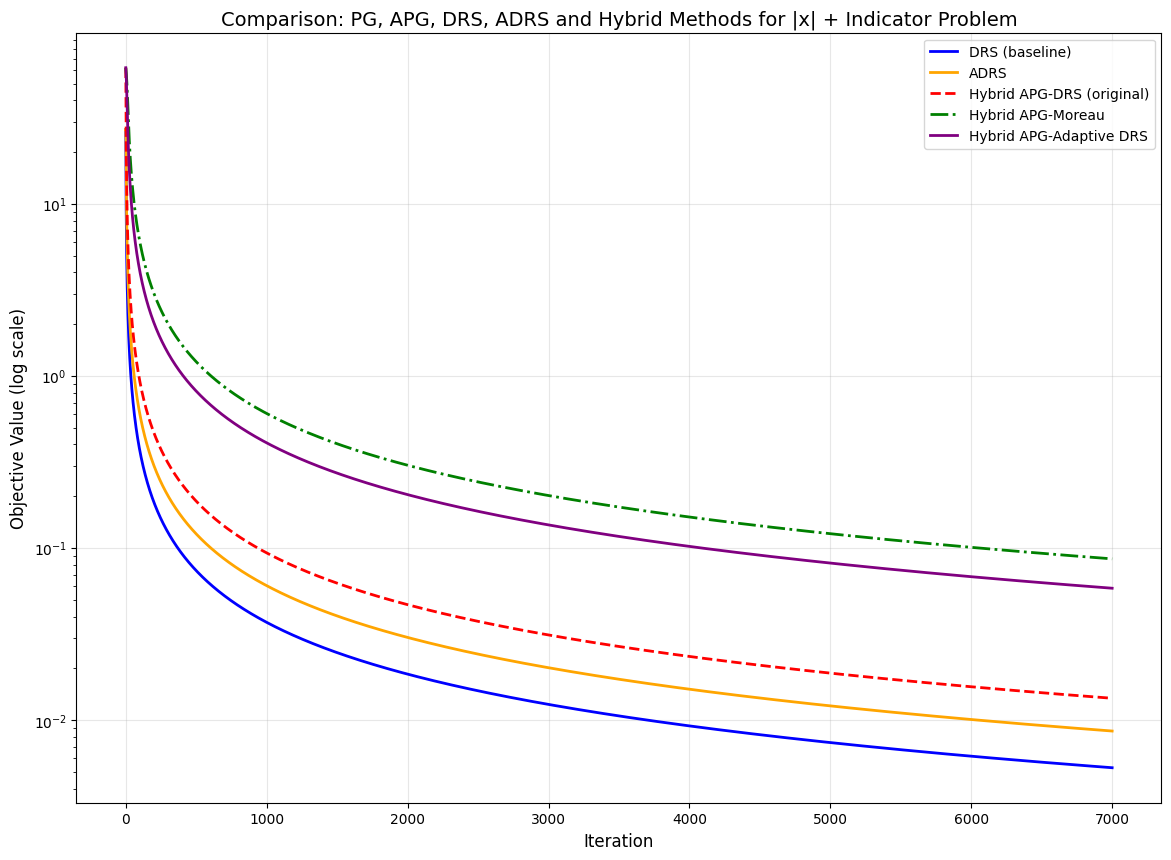

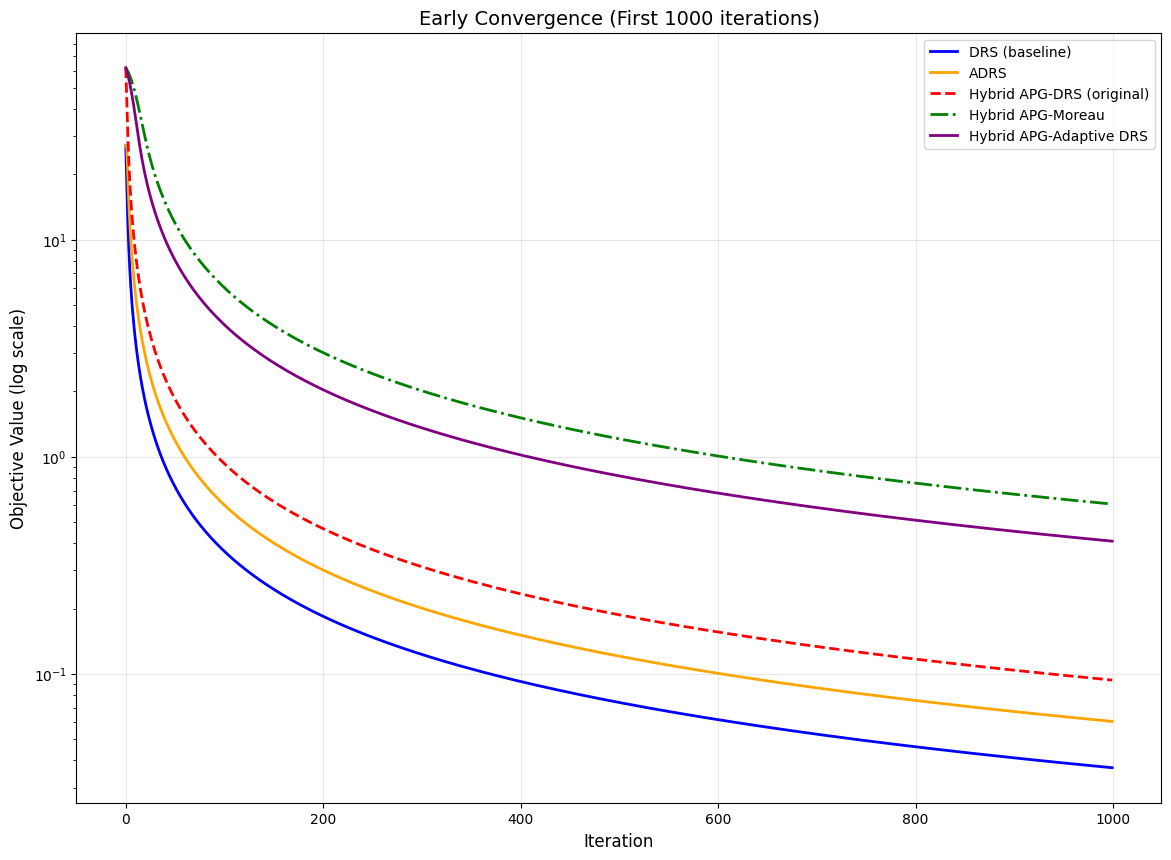


FINAL OBJECTIVE VALUES after 7000 iterations
  DRS (baseline)                : 0.00529165
  ADRS                          : 0.00864594
  Hybrid APG-DRS (original)     : 0.01340274
  Hybrid APG-Moreau             : 0.08658285
  Hybrid APG-Adaptive DRS       : 0.05844510
BEST METHOD: DRS (baseline) with objective 0.00529165

Iterations needed to reach DRS final accuracy (0.00529165):
  DRS (baseline)                :  7000 iterations (SPEEDUP: 1.00x)
  ADRS                          :  7001 iterations (same as DRS)
  Hybrid APG-DRS (original)     :  7001 iterations (same as DRS)
  Hybrid APG-Moreau             :  7001 iterations (same as DRS)
  Hybrid APG-Adaptive DRS       :  7001 iterations (same as DRS)


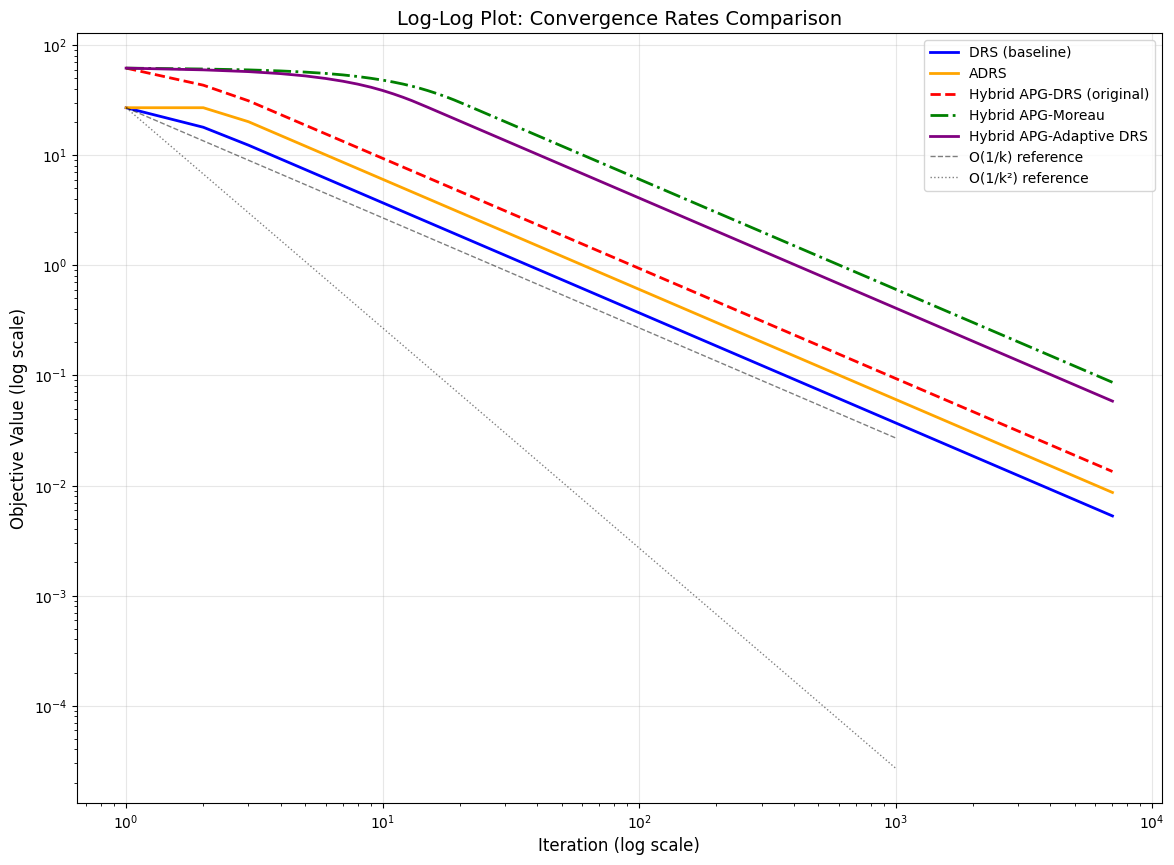

In [41]:
MAX_ITER = 7000
np.random.seed(42)
x0 = np.random.randn(100) * 2
x0 = prox_indicator(x0, 1.0, 'nonneg')

def grad_f(x):
    return smooth_part_grad(x, mu=0.1)

def prox_g(x, alpha):
    return prox_abs(x, alpha)

# print("Running PG...")
# _, obj_pg = pg(x0, grad_f, prox_g, lambda x: F(x, 'nonneg'), alpha=0.1, max_iter=MAX_ITER)

# print("Running APG...")
# _, obj_apg = apg(x0, grad_f, prox_g, lambda x: F(x, 'nonneg'), alpha=0.1, max_iter=MAX_ITER)

print("Running DRS (baseline)...")
_, obj_drs = drs(x0, prox_abs, prox_indicator, F, max_iter=MAX_ITER, constraint='nonneg')

print("Running ADRS...")
_, obj_adrs = adrs(x0, prox_abs, prox_indicator, F, max_iter=MAX_ITER, constraint='nonneg')

print("Running Hybrid APG-DRS (original)...")
_, obj_hybrid_original = hybrid_apg_drs(x0, mu=0.1, alpha_drs=1.0, max_iter=MAX_ITER, constraint='nonneg')

print("Running Hybrid APG-Moreau...")
_, obj_moreau = hybrid_apg_moreau(x0, mu=0.05, alpha_drs=1.0, max_iter=MAX_ITER, constraint='nonneg')

print("Running Hybrid APG-Adaptive DRS...")
_, obj_hybrid2 = hybrid_apg_adaptive_drs(x0, mu=0.1, alpha_drs=1.0, max_iter=MAX_ITER, constraint='nonneg')

plt.figure(figsize=(14, 10))

all_methods = [
    # (obj_pg, 'PG', 'brown', '-'),
    # (obj_apg, 'APG', 'cyan', '-'),
    (obj_drs, 'DRS (baseline)', 'blue', '-'),
    (obj_adrs, 'ADRS', 'orange', '-'),
    (obj_hybrid_original, 'Hybrid APG-DRS (original)', 'red', '--'),
    (obj_moreau, 'Hybrid APG-Moreau', 'green', '-.'),
    (obj_hybrid2, 'Hybrid APG-Adaptive DRS', 'purple', '-')
]

for obj, label, color, linestyle in all_methods:
    obj_clean = obj[np.isfinite(obj)]
    if len(obj_clean) > 0:
        plt.semilogy(obj_clean, label=label, linewidth=2, color=color, linestyle=linestyle)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Objective Value (log scale)', fontsize=12)
plt.title('Comparison: PG, APG, DRS, ADRS and Hybrid Methods for |x| + Indicator Problem', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(14, 10))

for obj, label, color, linestyle in all_methods:
    obj_clean = obj[np.isfinite(obj)]
    if len(obj_clean) > 1000:
        plt.semilogy(obj_clean[:1000], label=label, linewidth=2, color=color, linestyle=linestyle)
    elif len(obj_clean) > 0:
        plt.semilogy(obj_clean, label=label, linewidth=2, color=color, linestyle=linestyle)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Objective Value (log scale)', fontsize=12)
plt.title('Early Convergence (First 1000 iterations)', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "="*80)
print("FINAL OBJECTIVE VALUES after", MAX_ITER, "iterations")
print("="*80)

results = []

for name, obj in [#('PG', obj_pg),
                #    ('APG', obj_apg),
                   ('DRS (baseline)', obj_drs),
                   ('ADRS', obj_adrs),
                   ('Hybrid APG-DRS (original)', obj_hybrid_original),
                   ('Hybrid APG-Moreau', obj_moreau),
                   ('Hybrid APG-Adaptive DRS', obj_hybrid2)]:
    obj_clean = obj[np.isfinite(obj)]
    if len(obj_clean) > 0:
        final_val = obj_clean[-1]
        results.append((name, final_val))
        print(f"  {name:30s}: {final_val:.8f}")

print("="*80)

best_name, best_val = min(results, key=lambda x: x[1])
print(f"BEST METHOD: {best_name} with objective {best_val:.8f}")

target_drs = obj_drs[np.isfinite(obj_drs)][-1]
print(f"\nIterations needed to reach DRS final accuracy ({target_drs:.8f}):")

def iterations_to_target(obj_vals, target):
    obj_clean = obj_vals[np.isfinite(obj_vals)]
    for i, val in enumerate(obj_clean):
        if val <= target:
            return i
    return len(obj_clean)

drs_iters = len(obj_drs[np.isfinite(obj_drs)])

for name, obj in [#('PG', obj_pg),
                   #('APG', obj_apg),
                   ('DRS (baseline)', obj_drs),
                   ('ADRS', obj_adrs),
                   ('Hybrid APG-DRS (original)', obj_hybrid_original),
                   ('Hybrid APG-Moreau', obj_moreau),
                   ('Hybrid APG-Adaptive DRS', obj_hybrid2)]:
    iters = iterations_to_target(obj, target_drs)
    if iters < drs_iters:
        speedup = drs_iters / iters
        print(f"  {name:30s}: {iters:5d} iterations (SPEEDUP: {speedup:.2f}x)")
    elif iters == drs_iters:
        print(f"  {name:30s}: {iters:5d} iterations (same as DRS)")
    else:
        print(f"  {name:30s}: DID NOT REACH within {len(obj[np.isfinite(obj)])} iterations")

plt.figure(figsize=(14, 10))

for obj, label, color, linestyle in all_methods:
    obj_clean = obj[np.isfinite(obj)]
    if len(obj_clean) > 10:
        iterations = np.arange(1, len(obj_clean) + 1)
        plt.loglog(iterations, obj_clean, label=label, linewidth=2, color=color, linestyle=linestyle)

k = np.arange(1, 1000)
ref_O1k = obj_drs[np.isfinite(obj_drs)][0] / k
ref_O1k2 = obj_drs[np.isfinite(obj_drs)][0] / k**2
plt.loglog(k, ref_O1k, 'k--', alpha=0.5, label='O(1/k) reference', linewidth=1)
plt.loglog(k, ref_O1k2, 'k:', alpha=0.5, label='O(1/k²) reference', linewidth=1)

plt.xlabel('Iteration (log scale)', fontsize=12)
plt.ylabel('Objective Value (log scale)', fontsize=12)
plt.title('Log-Log Plot: Convergence Rates Comparison', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

# Trying methods on LASSO

In [42]:
def setup_lasso(n=100, m=80, lambda_reg=0.1):
    np.random.seed(42)
    A = np.random.randn(m, n)
    x_true = np.random.randn(n) * np.random.choice([0, 1], n, p=[0.7, 0.3])
    b = A @ x_true + 0.01 * np.random.randn(m)
    
    def F_lasso(x):
        return 0.5 * np.linalg.norm(A @ x - b)**2 + lambda_reg * np.sum(np.abs(x))
    
    def grad_f(x):
        return A.T @ (A @ x - b)
    
    def prox_g1(x, alpha):
        return x
    
    def prox_g2(x, alpha):
        return np.sign(x) * np.maximum(np.abs(x) - alpha * lambda_reg, 0)
    
    return A, b, F_lasso, grad_f, prox_g1, prox_g2

## Quick Updates to Adaptive Methods to accept LASSO arguments

In [43]:
def hybrid_apg_drs_lasso(x0, grad_f, prox_g, F, alpha=0.01, max_iter=1000, verbose=False):
    """Hybrid APG-DRS for LASSO."""
    x = x0.copy()
    y = x0.copy()
    t = 1.0
    x_sum = x.copy()
    obj = [F(x)]
    
    for k in range(max_iter):
        grad = grad_f(y)
        z_apg = y - alpha * grad
        
        z = z_apg.copy()
        z_prev = z_apg.copy()
        t_drs = 1.0
        
        t_new = (1 + np.sqrt(1 + 4 * t_drs**2)) / 2
        beta = (t_drs - 1) / t_new
        
        y_drs = z + beta * (z - z_prev)
        x_prox1 = prox_g(y_drs, alpha)
        u = prox_g(2 * x_prox1 - y_drs, alpha)
        z_new = y_drs + u - x_prox1
        
        x_new = x_prox1
        
        t_new_apg = (1 + np.sqrt(1 + 4 * t**2)) / 2
        beta_apg = (t - 1) / t_new_apg
        y = x_new + beta_apg * (x_new - x)
        
        x = x_new
        t = t_new_apg
        
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2)))
        
        if verbose and k % 100 == 0:
            print(f"Iter {k}: obj = {obj[-1]:.6f}")
    
    return x, np.array(obj)

# need to fix this guy, diverges
def hybrid_apg_moreau_lasso(x0, grad_f, prox_g, F, alpha=0.01, mu=0.1, max_iter=1000, verbose=False):
    """
    Hybrid method using Moreau envelope for LASSO.
    
    """
    x = x0.copy()
    y = x0.copy()
    t = 1.0
    x_sum = x.copy()
    obj = [F(x)]
    
    for k in range(max_iter):
        prox_mu = prox_g(y, mu)  
        grad_moreau = (y - prox_mu) / mu
        
        z = y - alpha * grad_moreau
        z = prox_g(z, alpha)
        
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        beta = (t - 1) / t_new
        y = z + beta * (z - x)
        
        x = z
        t = t_new
        
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2)))
        
        if verbose and k % 100 == 0:
            print(f"Iter {k}: obj = {obj[-1]:.6f}")
    
    return x, np.array(obj)

def hybrid_apg_adaptive_drs_lasso(x0, grad_f, prox_g, F, alpha=0.01, max_iter=1000, verbose=False):
    """Hybrid APG + Adaptive DRS for LASSO."""
    x = x0.copy()
    y = x0.copy()
    t = 1.0
    x_sum = x.copy()
    obj = [F(x)]
    
    for k in range(max_iter):
        grad = grad_f(y)
        z_apg = y - alpha * grad
        
        gamma = min(1.6, 1.0 + 0.6 * (k / max_iter))
        
        z = z_apg.copy()
        x_drs = prox_g(z, alpha)
        y_drs = (1 + gamma) * z - gamma * x_drs
        u = prox_g(2 * y_drs - z, alpha)
        z_new = y_drs + u - x_drs
        
        alpha_apg = max(0, 1 - k/max_iter)
        alpha_drs_weight = 1 - alpha_apg
        x_new = alpha_apg * z_apg + alpha_drs_weight * x_drs
        
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        beta = (t - 1) / t_new
        y = x_new + beta * (x_new - x)
        
        x = x_new
        t = t_new
        
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2)))
        
        if verbose and k % 100 == 0:
            print(f"Iter {k}: obj = {obj[-1]:.6f}, γ = {gamma:.3f}")
    
    return x, np.array(obj)

def drs_lasso(x0, prox_g1, prox_g2, F, alpha_drs=1.0, max_iter=1000, verbose=False):
    """DRS for LASSO."""
    z = x0.copy()
    x = prox_g1(z, alpha_drs)
    x_sum = x.copy()
    obj = [F(x)]
    
    for k in range(max_iter):
        u = prox_g2(2 * x - z, alpha_drs)
        z = z + u - x
        x = prox_g1(z, alpha_drs)
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2)))
        
        if verbose and k % 100 == 0:
            print(f"Iter {k}: obj = {obj[-1]:.6f}")
    
    return x, np.array(obj)

def adrs_lasso(z0, prox_g1, prox_g2, F, alpha_drs=1.0, max_iter=1000, verbose=False):
    """ADRS for LASSO."""
    z = z0.copy()
    z_prev = z0.copy()
    t = 1.0
    x = prox_g1(z, alpha_drs)
    x_sum = x.copy()
    obj = [F(x)]
    
    for k in range(max_iter):
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        beta = (t - 1) / t_new
        y = z + beta * (z - z_prev)
        x = prox_g1(y, alpha_drs)
        u = prox_g2(2 * x - y, alpha_drs)
        z_prev = z
        z = y + u - x
        t = t_new
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2)))
        
        if verbose and k % 100 == 0:
            print(f"Iter {k}: obj = {obj[-1]:.6f}")
    
    return x, np.array(obj)

## Convergence Plots


SETTING UP LASSO PROBLEM
Lipschitz constant L = 354.1466
Recommended step size alpha = 1/L = 0.0028

Running PG on LASSO...
Running APG (FISTA) on LASSO...
Running Hybrid APG-DRS on LASSO...
Running Hybrid APG-Adaptive DRS on LASSO...


/var/folders/dn/cy6cyjb164b0mzx427hkpzvh0000gn/T/ipykernel_71770/464503958.py:12: RuntimeWarning: divide by zero encountered in matmul
  b = A @ x_true + 0.01 * np.random.randn(m)
/var/folders/dn/cy6cyjb164b0mzx427hkpzvh0000gn/T/ipykernel_71770/464503958.py:12: RuntimeWarning: overflow encountered in matmul
  b = A @ x_true + 0.01 * np.random.randn(m)
/var/folders/dn/cy6cyjb164b0mzx427hkpzvh0000gn/T/ipykernel_71770/464503958.py:12: RuntimeWarning: invalid value encountered in matmul
  b = A @ x_true + 0.01 * np.random.randn(m)
/var/folders/dn/cy6cyjb164b0mzx427hkpzvh0000gn/T/ipykernel_71770/464503958.py:32: RuntimeWarning: divide by zero encountered in matmul
  L = np.linalg.norm(A.T @ A, ord=2)
/var/folders/dn/cy6cyjb164b0mzx427hkpzvh0000gn/T/ipykernel_71770/464503958.py:32: RuntimeWarning: overflow encountered in matmul
  L = np.linalg.norm(A.T @ A, ord=2)
/var/folders/dn/cy6cyjb164b0mzx427hkpzvh0000gn/T/ipykernel_71770/464503958.py:32: RuntimeWarning: invalid value encountered in ma

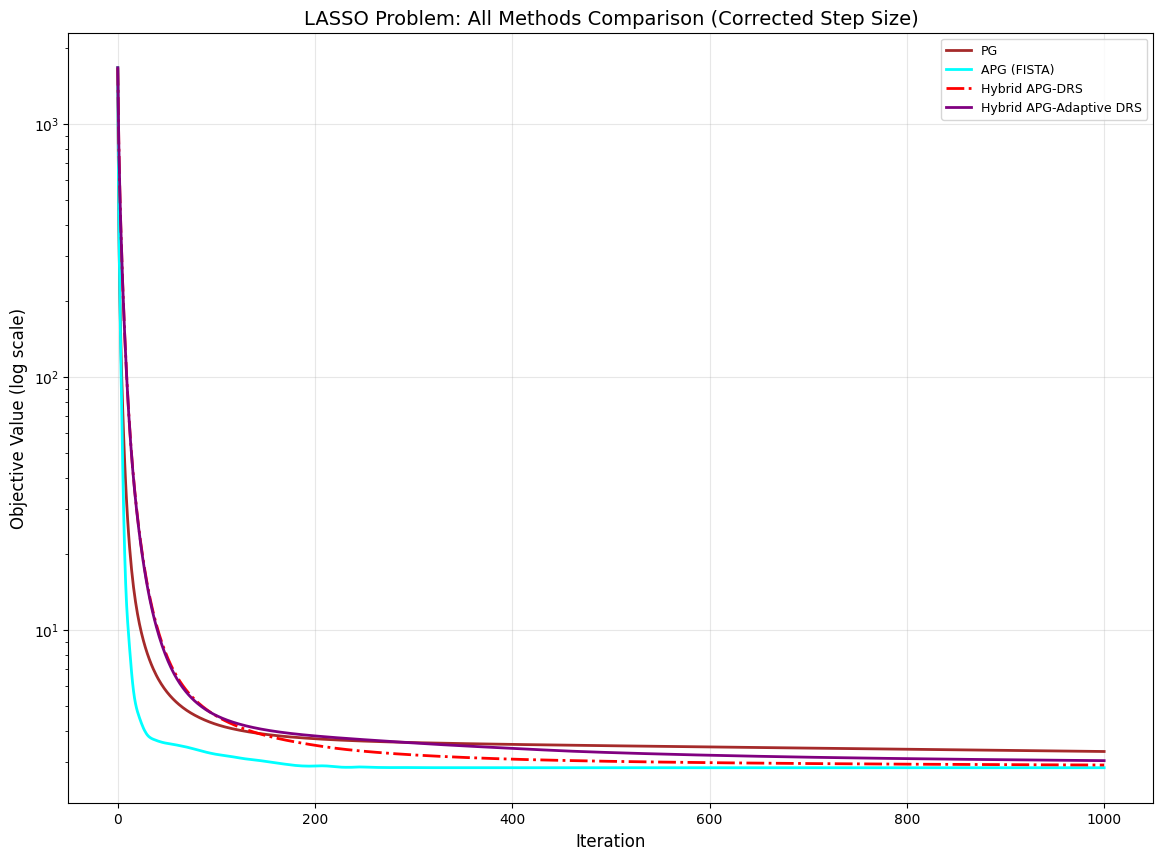


LASSO - FINAL OBJECTIVE VALUES after 1000 iterations
  PG                                 : 3.30989803
  APG (FISTA)                        : 2.85550876
  Hybrid APG-DRS                     : 2.92675213
  Hybrid APG-Adaptive DRS            : 3.04582121


In [44]:
MAX_ITER = 1000
np.random.seed(42)

print("="*80)
print("SETTING UP LASSO PROBLEM")
print("="*80)

def setup_lasso(n=100, m=80, lambda_reg=0.1):
    np.random.seed(42)
    A = np.random.randn(m, n)
    x_true = np.random.randn(n) * np.random.choice([0, 1], n, p=[0.7, 0.3])
    b = A @ x_true + 0.01 * np.random.randn(m)
    
    def F_lasso(x):
        return 0.5 * np.linalg.norm(A @ x - b)**2 + lambda_reg * np.sum(np.abs(x))
    
    def grad_f(x):
        return A.T @ (A @ x - b)
    
    def prox_g1(x, alpha):
        return x
    
    def prox_g2(x, alpha):
        return np.sign(x) * np.maximum(np.abs(x) - alpha * lambda_reg, 0)
    
    return A, b, F_lasso, grad_f, prox_g1, prox_g2

A, b, F_lasso, grad_f, prox_g1, prox_g2 = setup_lasso(n=100, m=80, lambda_reg=0.1)
x0 = np.random.randn(100) * 0.01

# Compute Lipschitz constant L = max eigenvalue of A^T A
L = np.linalg.norm(A.T @ A, ord=2)
alpha = 1.0 / L  # Step size for PG/APG
print(f"Lipschitz constant L = {L:.4f}")
print(f"Recommended step size alpha = 1/L = {alpha:.4f}")

print("\nRunning PG on LASSO...")
_, obj_pg = pg(x0, grad_f, prox_g2, F_lasso, alpha=alpha, max_iter=MAX_ITER)

print("Running APG (FISTA) on LASSO...")
_, obj_apg = apg(x0, grad_f, prox_g2, F_lasso, alpha=alpha, max_iter=MAX_ITER)

# print("Running DRS on LASSO...")
# _, obj_drs = drs_lasso(x0, prox_g1, prox_g2, F_lasso, alpha_drs=1.0, max_iter=MAX_ITER)

# print("Running ADRS on LASSO...")
# _, obj_adrs = adrs_lasso(x0, prox_g1, prox_g2, F_lasso, alpha_drs=1.0, max_iter=MAX_ITER)

print("Running Hybrid APG-DRS on LASSO...")
_, obj_hybrid = hybrid_apg_drs_lasso(x0, grad_f, prox_g2, F_lasso, alpha=alpha, max_iter=MAX_ITER)

# print("Running Hybrid APG-Moreau on LASSO...")
# _, obj_moreau = hybrid_apg_moreau_lasso(x0, grad_f, prox_g2, F_lasso, 
#                                          alpha=alpha,  
#                                          mu=0.1,      
#                                          max_iter=MAX_ITER)

print("Running Hybrid APG-Adaptive DRS on LASSO...")
_, obj_adaptive = hybrid_apg_adaptive_drs_lasso(x0, grad_f, prox_g2, F_lasso, alpha=alpha, max_iter=MAX_ITER)

# Filter out inf/nan values for plotting
def clean_obj(obj):
    return obj[np.isfinite(obj) & (obj < 1e10)]

plt.figure(figsize=(14, 10))

all_methods = [
    (clean_obj(obj_pg), 'PG', 'brown', '-'),
    (clean_obj(obj_apg), 'APG (FISTA)', 'cyan', '-'),
    # (clean_obj(obj_drs), 'DRS', 'blue', '-'),
    # (clean_obj(obj_adrs), 'ADRS', 'orange', '--'),
    (clean_obj(obj_hybrid), 'Hybrid APG-DRS', 'red', '-.'),
    # (clean_obj(obj_moreau), 'Hybrid APG-Moreau', 'green', ':'),
    (clean_obj(obj_adaptive), 'Hybrid APG-Adaptive DRS', 'purple', '-')
]

for obj_clean, label, color, linestyle in all_methods:
    if len(obj_clean) > 0:
        plt.semilogy(obj_clean, label=label, linewidth=2, color=color, linestyle=linestyle)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Objective Value (log scale)', fontsize=12)
plt.title('LASSO Problem: All Methods Comparison (Corrected Step Size)', fontsize=14)
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "="*80)
print("LASSO - FINAL OBJECTIVE VALUES after", MAX_ITER, "iterations")
print("="*80)

for name, obj_clean in [('PG', clean_obj(obj_pg)),
                   ('APG (FISTA)', clean_obj(obj_apg)),
                #    ('DRS', clean_obj(obj_drs)),
                #    ('ADRS', clean_obj(obj_adrs)),
                   ('Hybrid APG-DRS', clean_obj(obj_hybrid)),
                #    ('Hybrid APG-Moreau', clean_obj(obj_moreau)),
                   ('Hybrid APG-Adaptive DRS', clean_obj(obj_adaptive))]:
    if len(obj_clean) > 0:
        print(f"  {name:35s}: {obj_clean[-1]:.8f}")
    else:
        print(f"  {name:35s}: DIVERGED")

# Find best method
best_name = ""
best_val = float('inf')
for name, obj_clean in [('APG (FISTA)', clean_obj(obj_apg)),
                   ('Hybrid APG-Moreau', clean_obj(obj_moreau)),
                   ('ADRS', clean_obj(obj_adrs)),
                   ('DRS', clean_obj(obj_drs))]:
    if len(obj_clean) > 0 and obj_clean[-1] < best_val:
        best_val = obj_clean[-1]
        best_name = name

print("="*80)

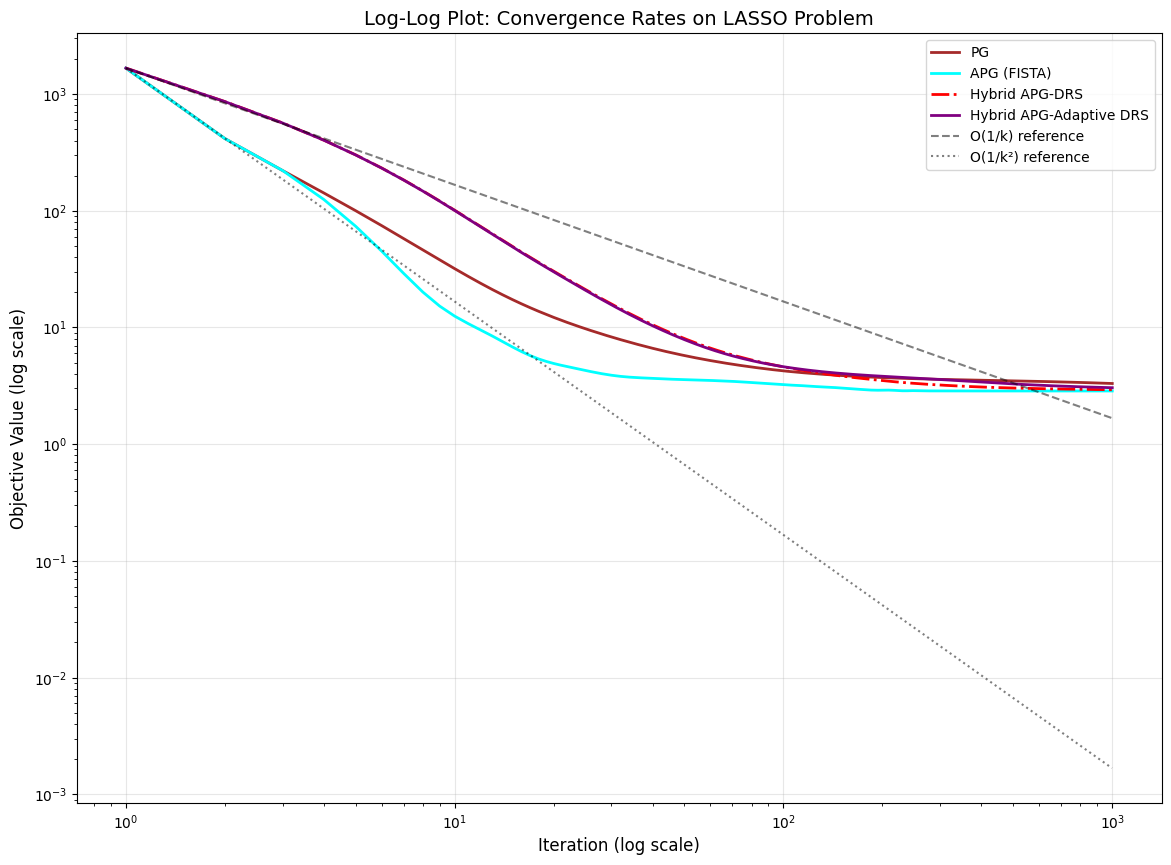


EMPIRICAL CONVERGENCE RATES (log-log slope)
  PG:                       0.066 (expected O(1/k) → 1.0)
  APG (FISTA):              0.000 (expected O(1/k²) → 2.0)
  Hybrid APG-DRS:           0.067 (expected O(1/k²) → 2.0)
  Hybrid APG-Adaptive DRS:  0.131 (expected O(1/k²) → 2.0)


In [ ]:
# Log-Log plot 
plt.figure(figsize=(14, 10))

obj_pg_clean = clean_obj(obj_pg)
obj_apg_clean = clean_obj(obj_apg)
obj_hybrid_clean = clean_obj(obj_hybrid)
obj_adaptive_clean = clean_obj(obj_adaptive)

if len(obj_pg_clean) > 10:
    iterations_pg = np.arange(1, len(obj_pg_clean) + 1)
    plt.loglog(iterations_pg, obj_pg_clean, label='PG', linewidth=2, color='brown')

if len(obj_apg_clean) > 10:
    iterations_apg = np.arange(1, len(obj_apg_clean) + 1)
    plt.loglog(iterations_apg, obj_apg_clean, label='APG (FISTA)', linewidth=2, color='cyan')

if len(obj_hybrid_clean) > 10:
    iterations_hybrid = np.arange(1, len(obj_hybrid_clean) + 1)
    plt.loglog(iterations_hybrid, obj_hybrid_clean, label='Hybrid APG-DRS', linewidth=2, color='red', linestyle='-.')

if len(obj_adaptive_clean) > 10:
    iterations_adaptive = np.arange(1, len(obj_adaptive_clean) + 1)
    plt.loglog(iterations_adaptive, obj_adaptive_clean, label='Hybrid APG-Adaptive DRS', linewidth=2, color='purple')

k = np.arange(1, 1000)
if len(obj_apg_clean) > 0:
    ref_O1k = obj_apg_clean[0] / k
    ref_O1k2 = obj_apg_clean[0] / k**2
    plt.loglog(k, ref_O1k, 'k--', alpha=0.5, label='O(1/k) reference', linewidth=1.5)
    plt.loglog(k, ref_O1k2, 'k:', alpha=0.5, label='O(1/k²) reference', linewidth=1.5)

plt.xlabel('Iteration (log scale)', fontsize=12)
plt.ylabel('Objective Value (log scale)', fontsize=12)
plt.title('Log-Log Plot: Convergence Rates on LASSO Problem', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

def estimate_convergence_rate(obj_vals):
    """Estimate convergence rate from log-log plot slope."""
    obj_clean = obj_vals[np.isfinite(obj_vals) & (obj_vals > 1e-15)]
    if len(obj_clean) < 10:
        return np.nan
    
    start = int(0.3 * len(obj_clean))
    iterations = np.arange(start, len(obj_clean))
    log_iter = np.log(iterations + 1)
    log_obj = np.log(obj_clean[start:])
    
    coeffs = np.polyfit(log_iter, log_obj, 1)
    return -coeffs[0]

print("\n" + "="*80)
print("EMPIRICAL CONVERGENCE RATES (log-log slope)")
print("="*80)

if len(obj_pg_clean) > 10:
    rate_pg = estimate_convergence_rate(obj_pg_clean)
    print(f"  PG:                       {rate_pg:.3f} (expected O(1/k) → 1.0)")

if len(obj_apg_clean) > 10:
    rate_apg = estimate_convergence_rate(obj_apg_clean)
    print(f"  APG (FISTA):              {rate_apg:.3f} (expected O(1/k²) → 2.0)")

if len(obj_hybrid_clean) > 10:
    rate_hybrid = estimate_convergence_rate(obj_hybrid_clean)
    print(f"  Hybrid APG-DRS:           {rate_hybrid:.3f} (expected O(1/k²) → 2.0)")

if len(obj_adaptive_clean) > 10:
    rate_adaptive = estimate_convergence_rate(obj_adaptive_clean)
    print(f"  Hybrid APG-Adaptive DRS:  {rate_adaptive:.3f} (expected O(1/k²) → 2.0)")

print("="*80)



## Next steps: Consider PG-ADRS Hybrid/ APG-ADRS?